# End-to-end fine-tuning (E5)

Fine-tunes seven encoders with a regression head, so the encoder itself
learns the task. Every other arm in this study keeps the encoder frozen: it
emits vectors and a separate classical model learns from them, so the
transformer never learns anything about depression severity. Here the
prediction error backpropagates through the whole encoder.

**What the seven arms are for.** They answer three questions that the frozen
grid cannot:

1. *Capacity*: e5-small, e5-base and e5-large span 118M to 560M parameters
   on one pretraining recipe. Frozen, capacity helped monotonically.
   Fine-tuned the risk runs the other way, because more parameters overfit
   a few hundred training rows more easily.
2. *Monolingual against multilingual*: BETO and BERTIN are pretrained on
   Spanish alone, the e5 and XLM-R checkpoints on a hundred languages at
   once. Spanish-only pretraining spends its whole capacity on this
   language; multilingual pretraining sees far more text.
3. *Architecture*: mDeBERTa-v3 against XLM-R is a controlled pair, same
   pretraining corpus (CC100) and near-identical size, differing in
   DeBERTa's disentangled attention. Without XLM-R in the comparison, a win
   for mDeBERTa could not be attributed to the architecture.

A caution for the write-up: mDeBERTa, XLM-R and e5-base carry ~279M
parameters but ~192M of those are the embedding table for a 250k vocabulary.
Their actual encoders are ~86M, the same as BETO's. Ranking these models by
total parameter count would be measuring vocabulary size.

**Spanish RoBERTa.** MarIA (PlanTL-GOB-ES/roberta-base-bne) would be the
other obvious candidate, but its weights are no longer published: the repo
returns 404 for its configuration and only third-party fine-tuned forks
remain on the hub. BERTIN covers the Spanish RoBERTa slot instead.

**Starting from the unadapted checkpoints.** The protocol originally had E5
fine-tune the TSDAE-adapted encoder, but that adaptation measurably degraded
the representation at every epoch budget tested (notebook 03), so starting
there would begin with a known handicap.

**Training setup.** One row per answered question, cross-validation-free:
early stopping on a validation slice split by participant, layer-wise
learning-rate decay so the lower layers move least, and warmup. Predictions
are averaged back per participant before any metric, so these arms are
scored on the same held-out people as notebooks 01-03 and compare directly.

**All metrics reported below are on the held-out test participants**: RMSE,
MAE and R2 for the regression, plus severity bands and screening positives
derived from the same continuous prediction for the confusion matrices.
Results are written under results/fine-tuning/, separate from the frozen
encoder grid, and each run's per-participant predictions are kept alongside
them so the arms can later be compared with paired tests.

In [19]:
%load_ext autoreload
%autoreload 2

import sys
import time
import warnings
from dataclasses import replace
from pathlib import Path

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display

from src import config, data, splits, logging_utils
from src.finetuning import run_finetune_arm
from src.pipeline import TARGETS, build_train_frame, expand_to_questions
from src.plotting import plot_confusion_matrix, BAND_LABELS, SCREENING_LABELS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Run configuration

Parameter counts are the full model including embeddings; the second figure
is the encoder alone, which is the part that does the work.

In [20]:
ARMS = {
    # Capacity ladder on one pretraining recipe.
    "E5_E5SMALL_FT":  "intfloat/multilingual-e5-small",              # 118M / 86M enc
    "E5_E5BASE_FT":   "intfloat/multilingual-e5-base",               # 278M / 86M enc
    "E5_E5LARGE_FT":  "intfloat/multilingual-e5-large",              # 560M / 303M enc
    # Spanish-only pretraining.
    "E5_BETO_FT":     "dccuchile/bert-base-spanish-wwm-cased",       # 110M / 86M enc
    "E5_BERTIN_FT":   "bertin-project/bertin-roberta-base-spanish",  # 125M / 86M enc
    # Architecture pair: same corpus and size, different attention.
    "E5_MDEBERTA_FT": "microsoft/mdeberta-v3-base",                  # 279M / 86M enc
    "E5_XLMR_FT":     "xlm-roberta-base",                            # 278M / 86M enc
    # e5-large's own backbone, at the same size. Without it the e5-large arm
    # has no control: its nearest one is xlm-roberta-BASE, so the gap between
    # them mixes 303M of encoder against 86M with e5's contrastive
    # pretraining against none. This pairing isolates the second.
    "E5_XLMRLARGE_FT": "xlm-roberta-large",                          # 560M / 303M enc
    # Adapted encoders (Phase C), fine-tuned from the same recipe as the arms
    # above, so each is paired with the arm it started from.
    "E8_BETO_MLM_FT": str(config.MODELS_DIR / "mlm_beto" / "ep010"),   # BETO + our MLM/TAPT
    "E8_ROBERTAES_MENTAL_FT": config.MENTAL_ES_MODEL,                  # 355M / 303M enc
}

cfg = config.FineTuningConfig(
    augmentation=config.AUGMENTATION_NONE,   # <- AUGMENTATION_NONE  AUGMENTATION_LLM
    seeds=(42,),
    max_epochs=20,
    patience=4,
    batch_size=16,
    grad_accum_steps=1,
    max_tokens=512,
    lr_head=1e-4,
    lr_encoder_top=3e-5,
    llrd_decay=0.9,
    warmup_ratio=0.10,
    val_fraction=0.2,
    use_bf16=True,
)

# Escape hatch for an arm that runs out of memory at the shared batch size.
# Empty by default: e5-large, the only arm large enough to be at risk, has
# already been run at batch 16 on this machine, and overriding it now would
# put its re-run on a different optimizer trajectory than the rows already
# logged. If an arm does fail, halve batch_size and double grad_accum_steps
# so the effective batch stays 16:
#     OVERRIDES = {"E5_E5LARGE_FT": {"batch_size": 8, "grad_accum_steps": 2}}
OVERRIDES = {}

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"device: {torch.cuda.get_device_name(0)}  |  VRAM free {free/1e9:.1f} / {total/1e9:.1f} GB")
else:
    print("WARNING: no CUDA device; fine-tuning on CPU is impractical here")
cfg

device: NVIDIA GeForce RTX 4060 Ti  |  VRAM free 15.9 / 17.2 GB


FineTuningConfig(augmentation='no_augmentation', seeds=(42,), max_epochs=20, patience=4, batch_size=16, eval_batch_size=32, grad_accum_steps=1, max_tokens=512, lr_head=0.0001, lr_encoder_top=3e-05, llrd_decay=0.9, weight_decay=0.01, warmup_ratio=0.1, max_grad_norm=1.0, val_fraction=0.2, use_bf16=True)

In [21]:
df = data.load_dataset()
train_ids, test_ids = splits.train_test_participants(df)
train_frame, aug_groups = build_train_frame(df, train_ids, test_ids, config.TrainingConfig(
    augmentation=cfg.augmentation))
test_frame = df.loc[test_ids]

group_col = "original_participant" if aug_groups is not None else None
q_train = expand_to_questions(train_frame, group_col=group_col)
q_test = expand_to_questions(test_frame)

groups = q_train["group"].to_numpy()
test_groups = q_test["participant"].to_numpy()
N_TEST = len(test_frame)

print(f"train: {len(train_frame)} participants -> {len(q_train)} question rows")
print(f"test:  {N_TEST} participants -> {len(q_test)} question rows (evaluated per participant)")

train: 110 participants -> 376 question rows
test:  48 participants -> 168 question rows (evaluated per participant)


In [22]:
def report_arm(arm, run_rows):
    runs = pd.DataFrame(run_rows)
    print(f"[TEST] {arm}: RMSE / MAE / R2 on the {N_TEST} held-out participants, per seed")
    display(runs.pivot(index="seed", columns="target", values=["rmse", "mae", "r2"]).round(3))

    print("Epoch early stopping selected, per run:")
    display(runs.assign(stopped_epoch=[p["stopped_epoch"] for p in runs["selected_params"]])
                .pivot(index="seed", columns="target", values="stopped_epoch"))

    fig, axes = plt.subplots(2, 2, figsize=(9, 8))
    for i, target in enumerate(TARGETS):
        target_runs = runs[runs["target"] == target]
        best = target_runs.loc[target_runs["rmse"].idxmin()]
        seed = int(best["seed"])
        plot_confusion_matrix(axes[i, 0], best["band_confusion_matrix"], BAND_LABELS,
                                f"{target} severity bands (seed={seed})")
        plot_confusion_matrix(axes[i, 1], best["screening_confusion_matrix"], SCREENING_LABELS,
                                f"{target} screening, cutoff 10 (seed={seed})")
    plt.suptitle(f"[TEST] {arm}: derived from the same continuous prediction, best seed")
    plt.tight_layout()
    plt.show()


def train_and_report(arm):
    arm_cfg = replace(cfg, **OVERRIDES.get(arm, {}))
    if arm in OVERRIDES:
        print(f"  override: batch_size={arm_cfg.batch_size} x "
              f"grad_accum_steps={arm_cfg.grad_accum_steps}")
    t0 = time.time()
    rows = run_finetune_arm(arm, ARMS[arm], q_train, q_test, groups, test_groups,
                             arm_cfg, device)
    print(f"{arm} done in {(time.time()-t0)/60:.1f} min")
    report_arm(arm, rows)

## Arms

Ordered so that the six base-size arms finish before e5-large, which alone
costs about as long as the rest together. Each cell is independent: a run
logs its own rows, so an arm can be re-run or skipped without disturbing the
others.

### e5-small fine-tuned

118M parameters, the cheapest arm. Roughly 2-4 minutes for one seed x 2
targets.

Layer-wise decay assigns rates by position in the network, and the optimizer
asserts that no parameter is left unassigned. An earlier version matched by
name and left the BERT-family pooler out of the optimizer entirely, which
this arm and BETO were exposed to.

  E5_E5SMALL_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12435.81it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9804  *
    epoch  2  val_rmse(scaled) 0.9625  *
    epoch  3  val_rmse(scaled) 0.9679
    epoch  4  val_rmse(scaled) 0.9744
    epoch  5  val_rmse(scaled) 1.0469
    epoch  6  val_rmse(scaled) 1.0220
    -> rmse 5.396  mae 4.355  r2 0.036  (best epoch 2, 30s)
  E5_E5SMALL_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12437.47it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-small
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1201  *
    epoch  2  val_rmse(scaled) 1.1269
    epoch  3  val_rmse(scaled) 1.0607  *
    epoch  4  val_rmse(scaled) 1.0076  *
    epoch  5  val_rmse(scaled) 1.0937
    epoch  6  val_rmse(scaled) 0.9809  *
    epoch  7  val_rmse(scaled) 1.0965
    epoch  8  val_rmse(scaled) 1.2562
    epoch  9  val_rmse(scaled) 1.2439
    epoch 10  val_rmse(scaled) 1.2331
    -> rmse 4.920  mae 4.093  r2 0.044  (best epoch 6, 47s)
E5_E5SMALL_FT done in 1.3 min
[TEST] E5_E5SMALL_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target  GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.92  5.396  4.093  4.355  0.044  0.036

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,6,2


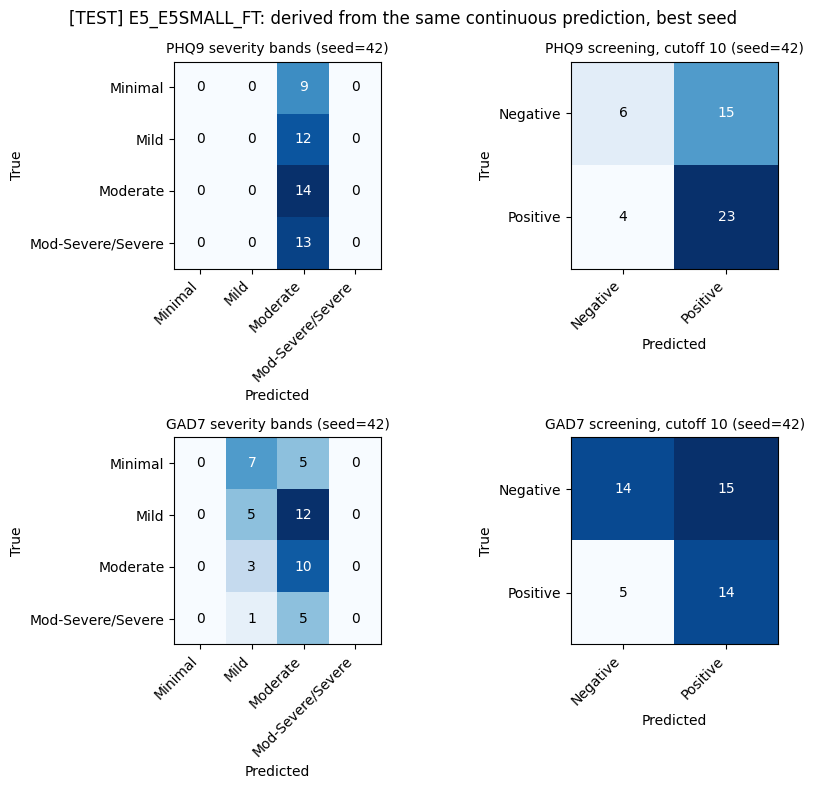

In [5]:
train_and_report("E5_E5SMALL_FT")

### e5-base fine-tuned

The middle rung of the capacity ladder, missing until now: without it, small
against large is two points and no shape.

  E5_E5BASE_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5180.07it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9536  *
    epoch  2  val_rmse(scaled) 0.8643  *
    epoch  3  val_rmse(scaled) 0.9239
    epoch  4  val_rmse(scaled) 0.9495
    epoch  5  val_rmse(scaled) 1.0093
    epoch  6  val_rmse(scaled) 0.9627
    -> rmse 4.301  mae 3.578  r2 0.387  (best epoch 2, 69s)
  E5_E5BASE_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8954.61it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-base
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.0046  *
    epoch  2  val_rmse(scaled) 1.0327
    epoch  3  val_rmse(scaled) 1.0542
    epoch  4  val_rmse(scaled) 1.2787
    epoch  5  val_rmse(scaled) 1.0619
    -> rmse 4.887  mae 4.105  r2 0.056  (best epoch 1, 57s)
E5_E5BASE_FT done in 2.1 min
[TEST] E5_E5BASE_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.887  4.301  4.105  3.578  0.056  0.387

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,1,2


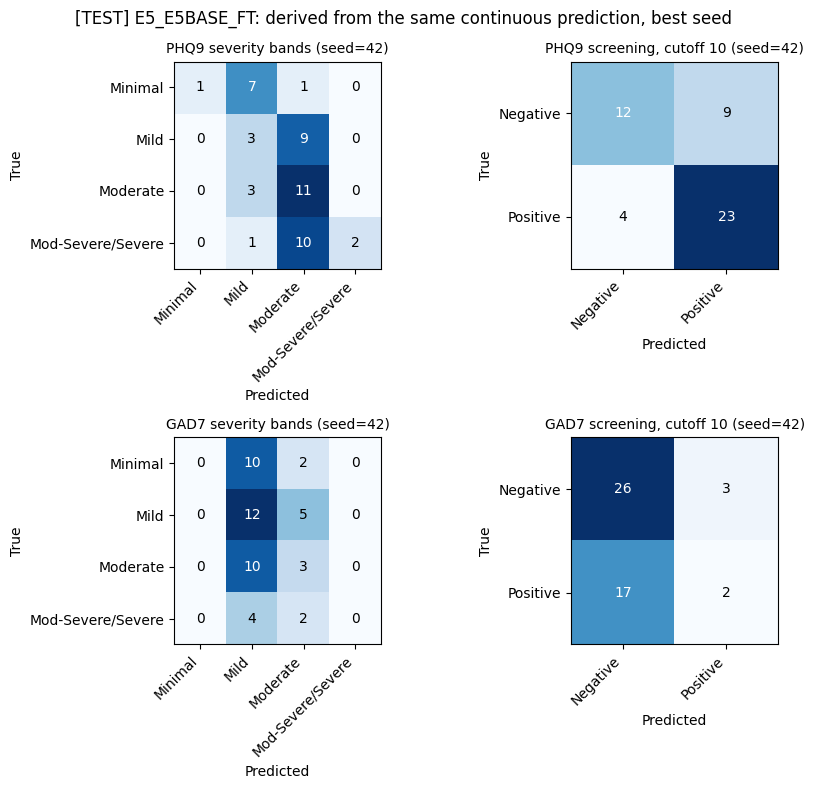

In [6]:
train_and_report("E5_E5BASE_FT")

### BETO fine-tuned

Spanish-only BERT, and the same checkpoint as the frozen E1 arm. That makes
this the one arm where frozen and fine-tuned differ in nothing but whether the
encoder was allowed to learn the task.

  E5_BETO_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 32831.80it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) 1.0215  *
    epoch  2  val_rmse(scaled) 0.9323  *
    epoch  3  val_rmse(scaled) 1.0568
    epoch  4  val_rmse(scaled) 1.0411
    epoch  5  val_rmse(scaled) 1.0175
    epoch  6  val_rmse(scaled) 1.0252
    -> rmse 4.504  mae 3.797  r2 0.328  (best epoch 2, 49s)
  E5_BETO_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 28144.90it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

    epoch  1  val_rmse(scaled) 1.1448  *
    epoch  2  val_rmse(scaled) 1.0157  *
    epoch  3  val_rmse(scaled) 1.1840
    epoch  4  val_rmse(scaled) 1.2406
    epoch  5  val_rmse(scaled) 1.0391
    epoch  6  val_rmse(scaled) 1.1398
    -> rmse 4.599  mae 3.809  r2 0.164  (best epoch 2, 48s)
E5_BETO_FT done in 1.6 min
[TEST] E5_BETO_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.599  4.504  3.809  3.797  0.164  0.328

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,2,2


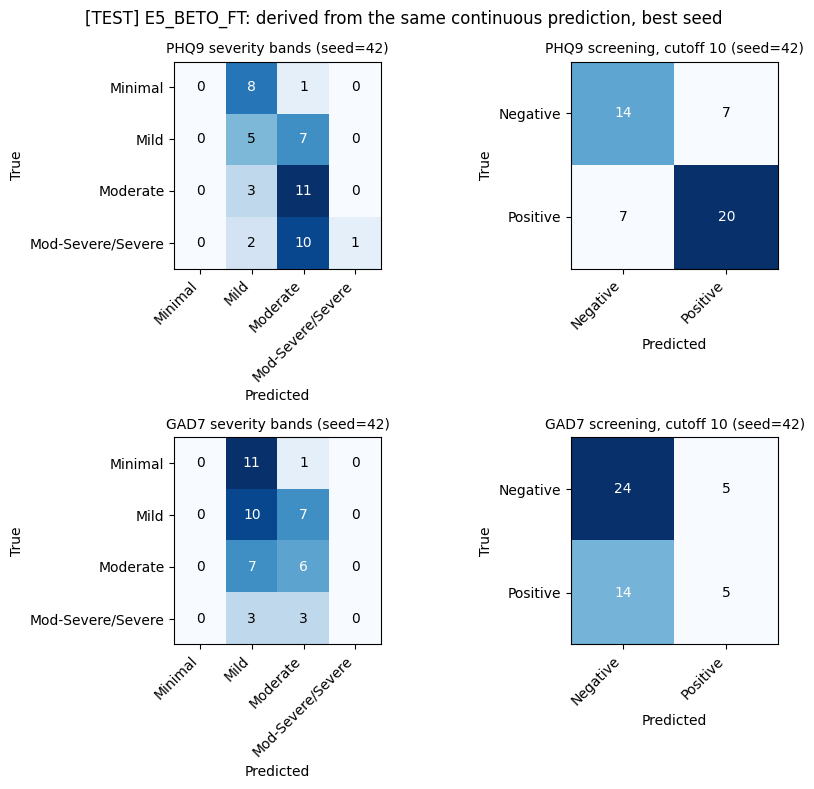

In [7]:
train_and_report("E5_BETO_FT")

### BERTIN fine-tuned

Spanish-only RoBERTa, trained on the Spanish portion of mC4. Pairs with BETO
to separate the pretraining objective from the language.

  E5_BERTIN_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5051.52it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9660  *
    epoch  2  val_rmse(scaled) 0.9737
    epoch  3  val_rmse(scaled) 0.9706
    epoch  4  val_rmse(scaled) 0.9053  *
    epoch  5  val_rmse(scaled) 0.8608  *
    epoch  6  val_rmse(scaled) 0.8878
    epoch  7  val_rmse(scaled) 0.8874
    epoch  8  val_rmse(scaled) 0.8640
    epoch  9  val_rmse(scaled) 0.9313
    -> rmse 4.853  mae 3.992  r2 0.220  (best epoch 5, 69s)
  E5_BERTIN_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8953.16it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1673  *
    epoch  2  val_rmse(scaled) 1.2185
    epoch  3  val_rmse(scaled) 1.0035  *
    epoch  4  val_rmse(scaled) 1.2067
    epoch  5  val_rmse(scaled) 1.0020  *
    epoch  6  val_rmse(scaled) 1.0202
    epoch  7  val_rmse(scaled) 1.1774
    epoch  8  val_rmse(scaled) 0.9824  *
    epoch  9  val_rmse(scaled) 1.1401
    epoch 10  val_rmse(scaled) 1.0972
    epoch 11  val_rmse(scaled) 1.0654
    epoch 12  val_rmse(scaled) 0.9955
    -> rmse 4.519  mae 3.610  r2 0.193  (best epoch 8, 89s)
E5_BERTIN_FT done in 2.6 min
[TEST] E5_BERTIN_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse          mae            r2      
target   GAD7   PHQ9  GAD7   PHQ9   GAD7  PHQ9
seed                                          
42      4.519  4.853  3.61  3.992  0.193  0.22

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,8,5


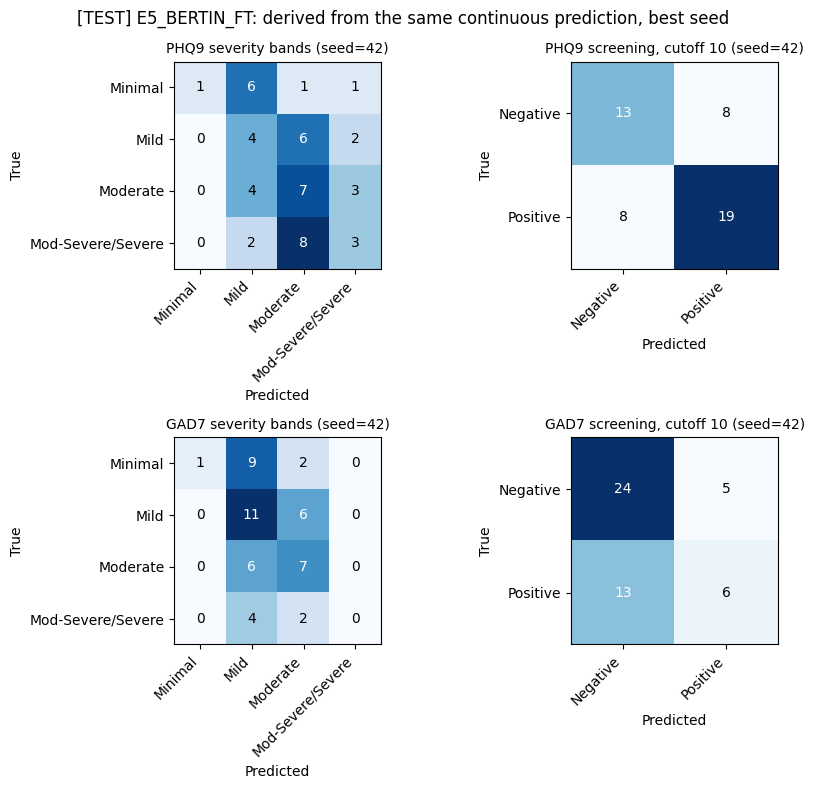

In [8]:
train_and_report("E5_BERTIN_FT")

### mDeBERTa-v3 fine-tuned

Disentangled attention with relative position encodings. Slower per step than
its size suggests, because the relative-attention machinery runs in every
layer.

This checkpoint is published in fp16 and its configuration declares no dtype,
so transformers infers half precision from the weight file itself. It is the
only one of the seven that does. Loading it that way meant training in pure
fp16 with no gradient scaler, which went non-finite at the second step; the
loader now forces fp32 master weights for every arm and leaves mixed precision
to autocast, as the other six already did. The learning rates are unchanged,
so this arm is not running under a regime of its own.

  E5_MDEBERTA_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 584.20it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
pooler.dens

    epoch  1  val_rmse(scaled) 0.9606  *
    epoch  2  val_rmse(scaled) 0.9426  *
    epoch  3  val_rmse(scaled) 0.8534  *
    epoch  4  val_rmse(scaled) 0.8877
    epoch  5  val_rmse(scaled) 1.0023
    epoch  6  val_rmse(scaled) 0.8955
    epoch  7  val_rmse(scaled) 0.9377
    -> rmse 4.845  mae 3.866  r2 0.223  (best epoch 3, 317s)
  E5_MDEBERTA_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 7136.73it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     | 
-------------------------------------------+------------+-
mask_predictions.classifier.bias           | UNEXPECTED | 
mask_predictions.classifier.weight         | UNEXPECTED | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED | 
mask_predictions.dense.weight              | UNEXPECTED | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED | 
mask_predictions.LayerNorm.bias            | UNEXPECTED | 
lm_predictions.lm_head.bias                | UNEXPECTED | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED | 
mask_predictions.LayerNorm.weight          | UNEXPECTED | 
mask_predictions.dense.bias                | UNEXPECTED | 
pooler.den

    epoch  1  val_rmse(scaled) 1.1425  *
    epoch  2  val_rmse(scaled) 1.2353
    epoch  3  val_rmse(scaled) 0.9841  *
    epoch  4  val_rmse(scaled) 1.1484
    epoch  5  val_rmse(scaled) 1.1104
    epoch  6  val_rmse(scaled) 1.0062
    epoch  7  val_rmse(scaled) 0.9842
    -> rmse 4.435  mae 3.387  r2 0.223  (best epoch 3, 303s)
E5_MDEBERTA_FT done in 10.3 min
[TEST] E5_MDEBERTA_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.435  4.845  3.387  3.866  0.223  0.223

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,3,3


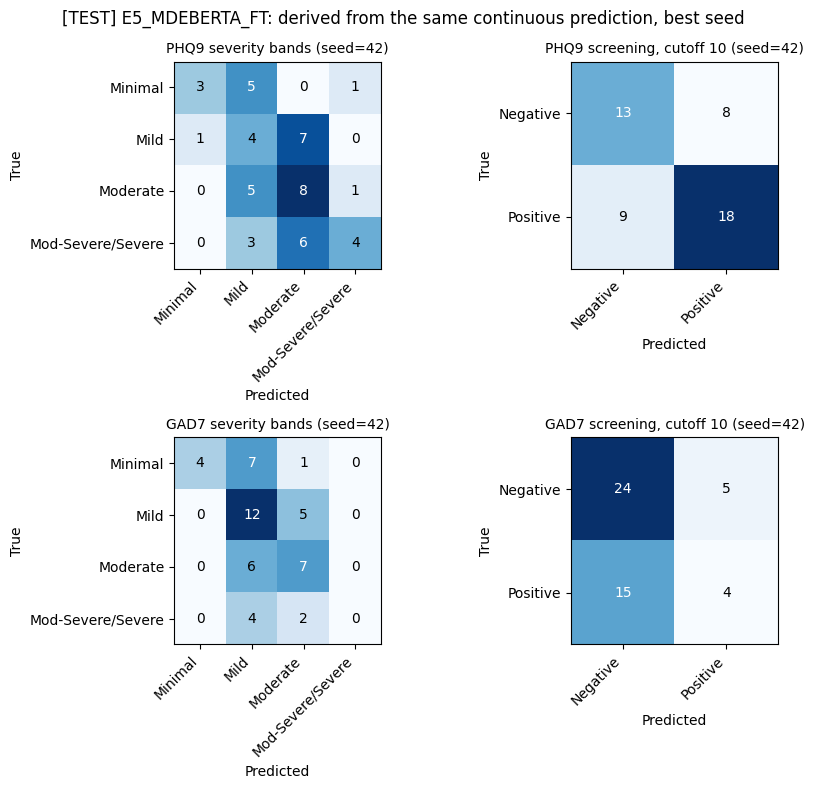

In [9]:
train_and_report("E5_MDEBERTA_FT")

### XLM-R base fine-tuned

The control for the arm above: same corpus, same vocabulary, same size, plain
attention. The difference between the two is the architecture's contribution.

  E5_XLMR_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5051.18it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9812  *
    epoch  2  val_rmse(scaled) 0.9208  *
    epoch  3  val_rmse(scaled) 0.8603  *
    epoch  4  val_rmse(scaled) 0.9510
    epoch  5  val_rmse(scaled) 0.9494
    epoch  6  val_rmse(scaled) 1.1061
    epoch  7  val_rmse(scaled) 1.0235
    -> rmse 4.491  mae 3.648  r2 0.332  (best epoch 3, 79s)
  E5_XLMR_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 11585.83it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1220  *
    epoch  2  val_rmse(scaled) 1.1561
    epoch  3  val_rmse(scaled) 1.0597  *
    epoch  4  val_rmse(scaled) 1.1045
    epoch  5  val_rmse(scaled) 1.0150  *
    epoch  6  val_rmse(scaled) 0.9454  *
    epoch  7  val_rmse(scaled) 0.9569
    epoch  8  val_rmse(scaled) 1.0727
    epoch  9  val_rmse(scaled) 0.9595
    epoch 10  val_rmse(scaled) 1.0557
    -> rmse 4.630  mae 3.727  r2 0.153  (best epoch 6, 110s)
E5_XLMR_FT done in 3.1 min
[TEST] E5_XLMR_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target  GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.63  4.491  3.727  3.648  0.153  0.332

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,6,3


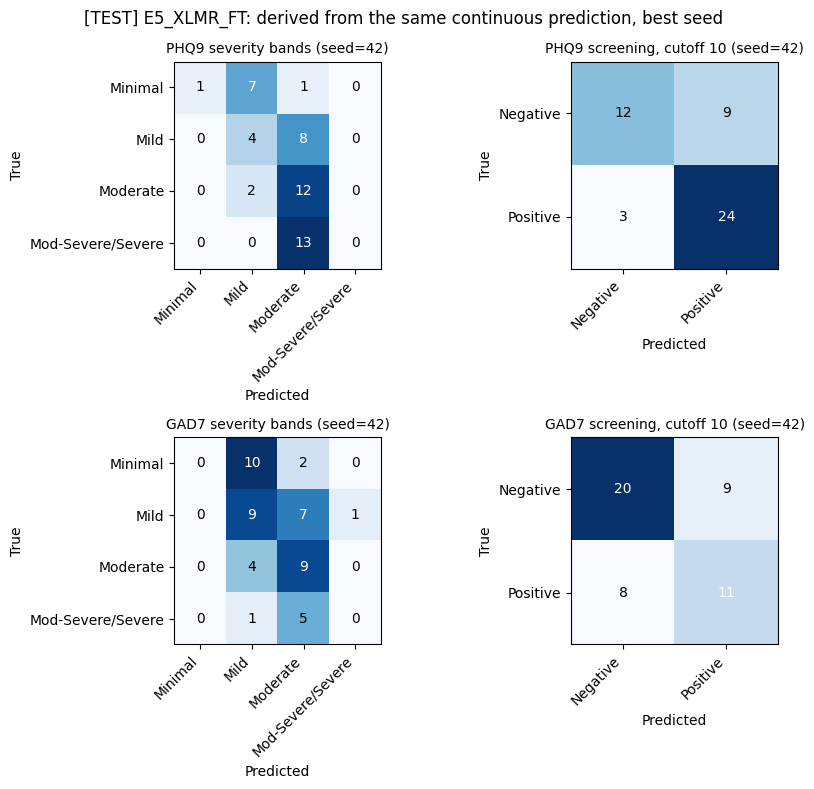

In [10]:
train_and_report("E5_XLMR_FT")

### e5-large fine-tuned

560M parameters and 24 layers, so this is the slow one (roughly 12 minutes
for one seed x 2 targets) and the one that can run out of memory. It has
completed at batch 16 on this machine; if it fails here, use OVERRIDES in the
configuration cell.

  E5_E5LARGE_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4799.69it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9467  *
    epoch  2  val_rmse(scaled) 0.8823  *
    epoch  3  val_rmse(scaled) 1.0316
    epoch  4  val_rmse(scaled) 0.9619
    epoch  5  val_rmse(scaled) 0.9918
    epoch  6  val_rmse(scaled) 0.9615
    -> rmse 4.393  mae 3.589  r2 0.361  (best epoch 2, 393s)
  E5_E5LARGE_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 12548.62it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: intfloat/multilingual-e5-large
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.weight        | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.2725  *
    epoch  2  val_rmse(scaled) 0.9262  *
    epoch  3  val_rmse(scaled) 1.0186
    epoch  4  val_rmse(scaled) 1.5463
    epoch  5  val_rmse(scaled) 0.9230  *
    epoch  6  val_rmse(scaled) 1.0012
    epoch  7  val_rmse(scaled) 1.0538
    epoch  8  val_rmse(scaled) 0.9769
    epoch  9  val_rmse(scaled) 1.1050
    -> rmse 4.318  mae 3.638  r2 0.263  (best epoch 5, 702s)
E5_E5LARGE_FT done in 18.2 min
[TEST] E5_E5LARGE_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.318  4.393  3.638  3.589  0.263  0.361

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,5,2


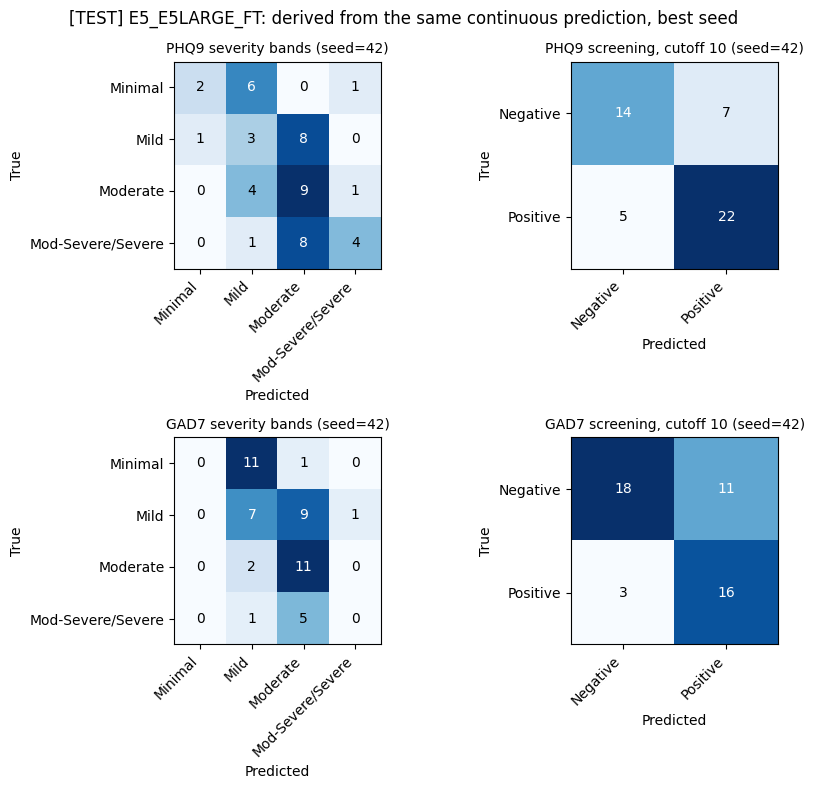

In [11]:
train_and_report("E5_E5LARGE_FT")

### XLM-R large fine-tuned

The control for e5-large. `multilingual-e5-large` is `xlm-roberta-large` with
a contrastive pretraining on top, so running the plain backbone at the same
size is what separates that pretraining from capacity.

Two things to keep in mind when reading the result. This family loads a
checkpoint through `AutoModelForSequenceClassification`, which discards the
sentence-transformer pooling and prefix that e5's extra training was built to
exploit, so the contrast is narrower than "does e5-large beat XLM-R large".
And `xlm-roberta-large` is known to be unstable to fine-tune: if this arm
scores near the mean predictor, check the per-epoch validation RMSE before
reading it as the backbone performing badly.

  E5_XLMRLARGE_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 7683.07it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9783  *
    epoch  2  val_rmse(scaled) 0.9732  *
    epoch  3  val_rmse(scaled) 0.9615  *
    epoch  4  val_rmse(scaled) 0.9712
    epoch  5  val_rmse(scaled) 0.9431  *
    epoch  6  val_rmse(scaled) 0.9888
    epoch  7  val_rmse(scaled) 0.9100  *
    epoch  8  val_rmse(scaled) 1.0319
    epoch  9  val_rmse(scaled) 0.9388
    epoch 10  val_rmse(scaled) 0.9947
    epoch 11  val_rmse(scaled) 0.9950
    -> rmse 4.687  mae 3.797  r2 0.272  (best epoch 7, 430s)
  E5_XLMRLARGE_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 4016.58it/s]
[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.0668  *
    epoch  2  val_rmse(scaled) 1.1148
    epoch  3  val_rmse(scaled) 1.1251
    epoch  4  val_rmse(scaled) 1.0391  *
    epoch  5  val_rmse(scaled) 1.0160  *
    epoch  6  val_rmse(scaled) 1.1429
    epoch  7  val_rmse(scaled) 1.1428
    epoch  8  val_rmse(scaled) 0.9984  *
    epoch  9  val_rmse(scaled) 1.0770
    epoch 10  val_rmse(scaled) 1.0798
    epoch 11  val_rmse(scaled) 1.1193
    epoch 12  val_rmse(scaled) 0.9876  *
    epoch 13  val_rmse(scaled) 1.0731
    epoch 14  val_rmse(scaled) 0.9406  *
    epoch 15  val_rmse(scaled) 1.0527
    epoch 16  val_rmse(scaled) 1.0305
    epoch 17  val_rmse(scaled) 1.0289
    epoch 18  val_rmse(scaled) 1.0355
    -> rmse 4.435  mae 3.550  r2 0.223  (best epoch 14, 554s)
E5_XLMRLARGE_FT done in 16.4 min
[TEST] E5_XLMRLARGE_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse          mae            r2       
target   GAD7   PHQ9  GAD7   PHQ9   GAD7   PHQ9
seed                                           
42      4.435  4.687  3.55  3.797  0.223  0.272

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,14,7


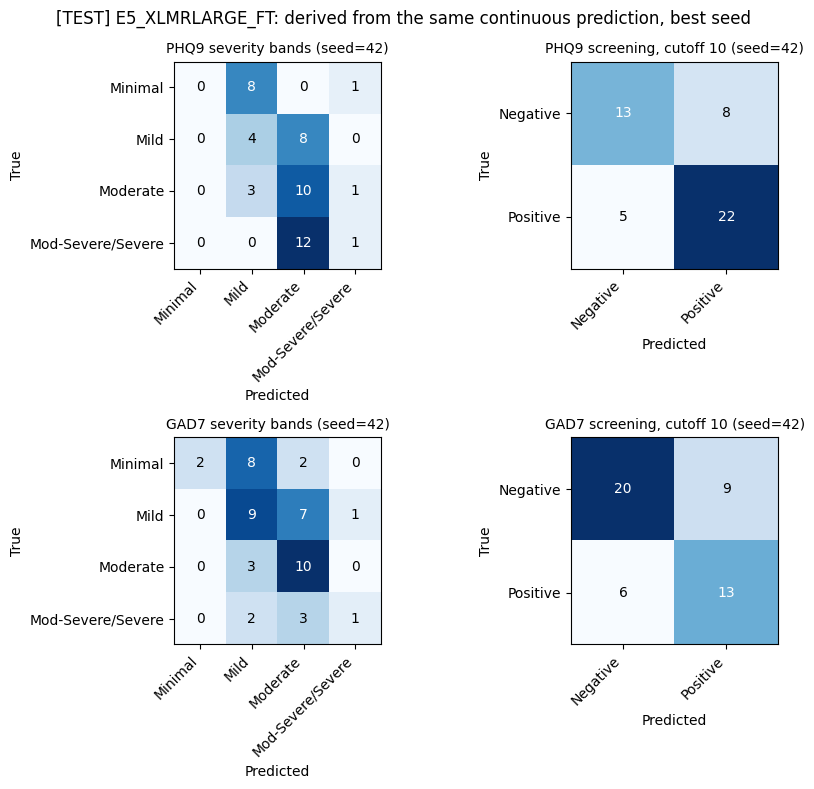

In [23]:
train_and_report("E5_XLMRLARGE_FT")

### BETO + MLM (TAPT) fine-tuned

The same BETO as `E5_BETO_FT`, after continued masked-language-model
pretraining on this study's own interviews (`scripts/run_beto_mlm.py`, epoch
10, the checkpoint with the lowest MLM validation perplexity on held-out
*training* participants). Its pair is `E5_BETO_FT`: same architecture, same
recipe, same data here — the only difference is the starting point, which is
what makes this the test of whether task-adaptive pretraining pays off once
the encoder is fine-tuned. Roughly the same cost as `E5_BETO_FT`.

  E8_BETO_MLM_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5794.33it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: models/mlm_beto\ep010
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

    epoch  1  val_rmse(scaled) 0.9870  *
    epoch  2  val_rmse(scaled) 0.8918  *
    epoch  3  val_rmse(scaled) 1.0011
    epoch  4  val_rmse(scaled) 0.9367
    epoch  5  val_rmse(scaled) 0.9581
    epoch  6  val_rmse(scaled) 0.9774
    -> rmse 4.502  mae 3.800  r2 0.329  (best epoch 2, 50s)
  E8_BETO_MLM_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8546.26it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: models/mlm_beto\ep010
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

    epoch  1  val_rmse(scaled) 1.1312  *
    epoch  2  val_rmse(scaled) 0.9129  *
    epoch  3  val_rmse(scaled) 1.0673
    epoch  4  val_rmse(scaled) 1.2065
    epoch  5  val_rmse(scaled) 1.0328
    epoch  6  val_rmse(scaled) 1.0224
    -> rmse 4.635  mae 3.842  r2 0.151  (best epoch 2, 47s)
E8_BETO_MLM_FT done in 1.6 min
[TEST] E8_BETO_MLM_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae          r2       
target   GAD7   PHQ9   GAD7 PHQ9   GAD7   PHQ9
seed                                          
42      4.635  4.502  3.842  3.8  0.151  0.329

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,2,2


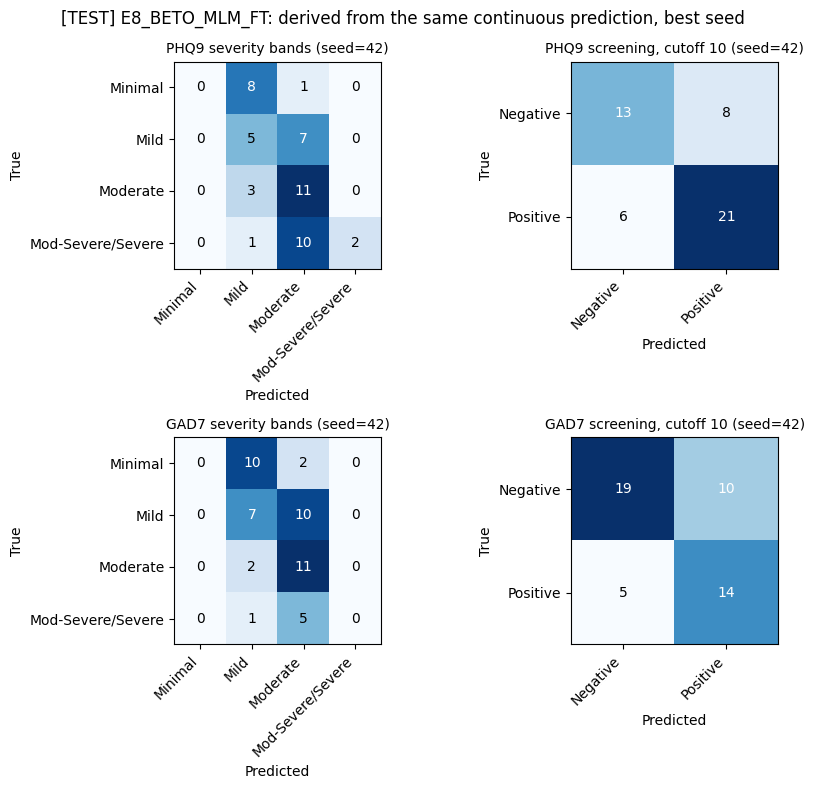

In [13]:
train_and_report("E8_BETO_MLM_FT")

### RoBERTa-es-mental fine-tuned

`ELiRF/RoBERTa-es-mental-large`: `roberta-large-bne` domain-adapted by others
on ~1.9M mental-health Reddit posts machine-translated into Spanish. Frozen it
matched BETO and stayed behind e5-large; this asks whether the adaptation pays
off once the encoder itself is trained.

At 355M parameters it is the second heaviest arm. If it runs out of memory at
the shared batch size, add it to `BATCH_OVERRIDES` above rather than changing
the batch size for every arm, so the recipe stays comparable.

  E8_ROBERTAES_MENTAL_FT seed=42 target=PHQ9


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5118.42it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 0.9508  *
    epoch  2  val_rmse(scaled) 0.9741
    epoch  3  val_rmse(scaled) 0.9238  *
    epoch  4  val_rmse(scaled) 0.9060  *
    epoch  5  val_rmse(scaled) 0.9243
    epoch  6  val_rmse(scaled) 0.9180
    epoch  7  val_rmse(scaled) 0.8929  *
    epoch  8  val_rmse(scaled) 0.8908  *
    epoch  9  val_rmse(scaled) 0.8971
    epoch 10  val_rmse(scaled) 0.9092
    epoch 11  val_rmse(scaled) 0.8835  *
    epoch 12  val_rmse(scaled) 0.8860
    epoch 13  val_rmse(scaled) 0.9021
    epoch 14  val_rmse(scaled) 0.8826  *
    epoch 15  val_rmse(scaled) 0.8902
    epoch 16  val_rmse(scaled) 0.8884
    epoch 17  val_rmse(scaled) 0.8876
    epoch 18  val_rmse(scaled) 0.8858
    -> rmse 4.461  mae 3.755  r2 0.341  (best epoch 14, 456s)
  E8_ROBERTAES_MENTAL_FT seed=42 target=GAD7


Loading weights: 100%|██████████| 389/389 [00:00<00:00, 12967.19it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: ELiRF/RoBERTa-es-mental-large
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


    epoch  1  val_rmse(scaled) 1.1729  *
    epoch  2  val_rmse(scaled) 1.0599  *
    epoch  3  val_rmse(scaled) 0.9186  *
    epoch  4  val_rmse(scaled) 1.3304
    epoch  5  val_rmse(scaled) 0.9975
    epoch  6  val_rmse(scaled) 0.9491
    epoch  7  val_rmse(scaled) 0.9450
    -> rmse 4.428  mae 3.677  r2 0.225  (best epoch 3, 179s)
E8_ROBERTAES_MENTAL_FT done in 10.6 min
[TEST] E8_ROBERTAES_MENTAL_FT: RMSE / MAE / R2 on the 48 held-out participants, per seed


rmse           mae            r2       
target   GAD7   PHQ9   GAD7   PHQ9   GAD7   PHQ9
seed                                            
42      4.428  4.461  3.677  3.755  0.225  0.341

Epoch early stopping selected, per run:


target,GAD7,PHQ9
seed,,
42,3,14


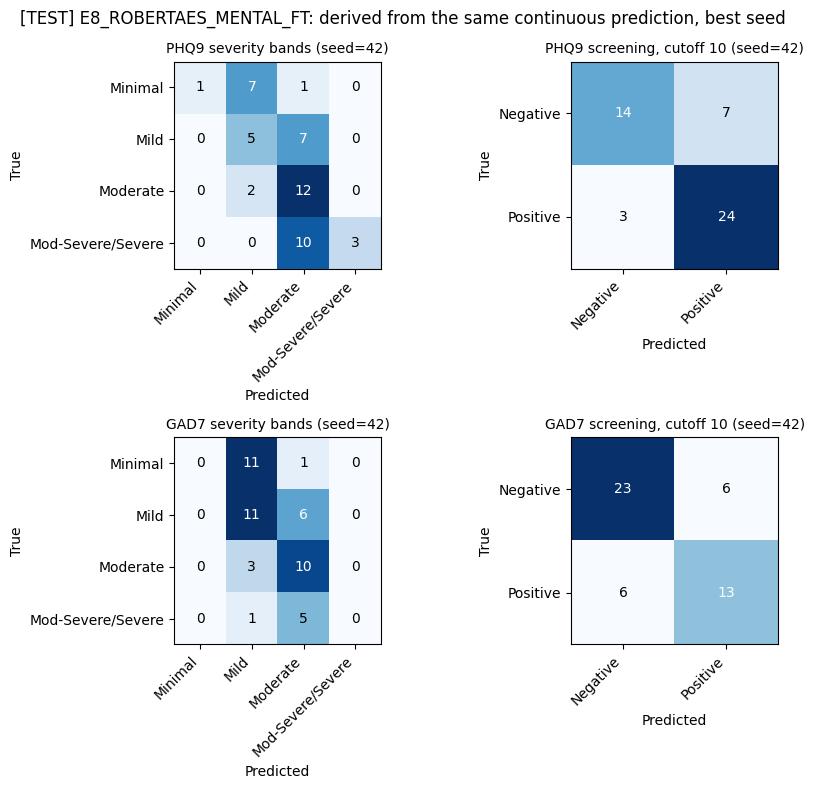

In [14]:
train_and_report("E8_ROBERTAES_MENTAL_FT")

## Fine-tuned against frozen

The frozen arms live in a different results tree, so both logs are read and
shown together. The comparison is valid because every arm is scored on the
same held-out participants.

The **question-level** frozen arms are the matched control: fine-tuning
trains on question rows by construction, so comparing against the
participant-averaged arms would confound method with input granularity.

Read the ranking with the number of arms in mind. Twenty-one arms are
measured on the same 48 people, and each is a single run at seed 42, so there
is no estimate of how much of a gap between two arms is measurement noise.
Earlier five-seed runs put that spread at up to 0.41 RMSE for the fine-tuned
arms, which is larger than most of the gaps this table will show. Treat the
ordering as descriptive: what it supports is the family-level reading below,
not a claim about which checkpoint is best.

In [15]:
both = logging_utils.load_all_runs()
both = both[both.augmentation == cfg.augmentation]

reference = ["E2_E5SMALL_QUESTION", "E2_E5BASE_QUESTION", "E2_E5LARGE_QUESTION",
             "E1_BETO_QUESTION", "E2_E5SMALL", "E2_E5LARGE", "E1_BETO"]
order = list(ARMS) + [r for r in reference if r in set(both.encoder)]

# `search` is part of the grouping so the frozen arms' tuned and defaults
# runs stay separate rather than being averaged into one number. The
# fine-tuned arms carry "finetuned", since no regressor is selected there.
summary = both[both.encoder.isin(order)].groupby(["encoder", "search", "target"])[
    ["rmse", "mae", "r2"]].agg(["mean", "std"]).round(3)

spread = (f"mean and SD across {len(cfg.seeds)} seeds" if len(cfg.seeds) > 1
          else f"single seed ({cfg.seeds[0]}), so the SD columns are empty")
print(f"[TEST] {spread}, on the {N_TEST} held-out participants.")
print("RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of")
print("variance explained (0 = no better than predicting the training mean).")
present = set(summary.index.get_level_values("encoder"))
display(summary.loc[[e for e in order if e in present]])

[TEST] single seed (42), so the SD columns are empty, on the 48 held-out participants.
RMSE and MAE in PHQ-9 / GAD-7 points (lower is better); R2 is the fraction of
variance explained (0 = no better than predicting the training mean).


rmse        mae         r2    
                                             mean std   mean std   mean std
encoder                search       target                                 
E5_E5SMALL_FT          finetuned    GAD7    4.920 NaN  4.093 NaN  0.044 NaN
                                    PHQ9    5.396 NaN  4.355 NaN  0.036 NaN
                       finetuned_cv GAD7    4.851 NaN  4.127 NaN  0.070 NaN
                                    PHQ9    4.642 NaN  3.879 NaN  0.286 NaN
E5_E5BASE_FT           finetuned    GAD7    4.887 NaN  4.105 NaN  0.056 NaN
                                    PHQ9    4.301 NaN  3.578 NaN  0.387 NaN
                       finetuned_cv GAD7    4.123 NaN  3.156 NaN  0.328 NaN
                                    PHQ9    4.366 NaN  3.684 NaN  0.369 NaN
E5_E5LARGE_FT          finetuned    GAD7    4.318 NaN  3.638 NaN  0.263 NaN
                                    PHQ9    4.393 NaN  3.589 NaN  0.361 NaN
                       finetuned_cv GAD7    4.075 NaN  2.986 NaN  0.344 NaN
                                    PHQ9    4.455 NaN  3.645 NaN  0.343 NaN
E5_BETO_FT             finetuned    GAD7    4.599 NaN  3.809 NaN  0.164 NaN
                                    PHQ9    4.504 NaN  3.797 NaN  0.328 NaN
                       finetuned_cv GAD7    4.261 NaN  3.373 NaN  0.283 NaN
                                    PHQ9    4.400 NaN  3.637 NaN  0.359 NaN
E5_BERTIN_FT           finetuned    GAD7    4.519 NaN  3.610 NaN  0.193 NaN
                                    PHQ9    4.853 NaN  3.992 NaN  0.220 NaN
                       finetuned_cv GAD7    4.559 NaN  3.465 NaN  0.179 NaN
                                    PHQ9    4.630 NaN  3.685 NaN  0.290 NaN
E5_MDEBERTA_FT         finetuned    GAD7    4.435 NaN  3.387 NaN  0.223 NaN
                                    PHQ9    4.845 NaN  3.866 NaN  0.223 NaN
                       finetuned_cv GAD7    4.533 NaN  3.464 NaN  0.188 NaN
                                    PHQ9    4.768 NaN  3.815 NaN  0.247 NaN
E5_XLMR_FT             finetuned    GAD7    4.630 NaN  3.727 NaN  0.153 NaN
                                    PHQ9    4.491 NaN  3.648 NaN  0.332 NaN
                       finetuned_cv GAD7    4.300 NaN  3.302 NaN  0.269 NaN
                                    PHQ9    4.489 NaN  3.687 NaN  0.333 NaN
E5_XLMRLARGE_FT        finetuned    GAD7    4.674 NaN  3.879 NaN  0.137 NaN
                                    PHQ9    4.518 NaN  3.653 NaN  0.324 NaN
E8_BETO_MLM_FT         finetuned    GAD7    4.635 NaN  3.842 NaN  0.151 NaN
                                    PHQ9    4.502 NaN  3.800 NaN  0.329 NaN
E8_ROBERTAES_MENTAL_FT finetuned    GAD7    4.428 NaN  3.677 NaN  0.225 NaN
                                    PHQ9    4.461 NaN  3.755 NaN  0.341 NaN
E2_E5SMALL_QUESTION    defaults     GAD7    4.465 NaN  3.654 NaN  0.212 NaN
                                    PHQ9    4.871 NaN  4.072 NaN  0.214 NaN
E2_E5BASE_QUESTION     defaults     GAD7    4.625 NaN  3.753 NaN  0.155 NaN
                                    PHQ9    4.723 NaN  4.036 NaN  0.261 NaN
E2_E5LARGE_QUESTION    defaults     GAD7    4.468 NaN  3.622 NaN  0.211 NaN
                                    PHQ9    4.632 NaN  3.815 NaN  0.289 NaN
E1_BETO_QUESTION       defaults     GAD7    4.527 NaN  3.703 NaN  0.190 NaN
                                    PHQ9    4.984 NaN  4.154 NaN  0.177 NaN
E2_E5SMALL             defaults     GAD7    4.372 NaN  3.569 NaN  0.245 NaN
                                    PHQ9    4.750 NaN  3.898 NaN  0.253 NaN
E2_E5LARGE             defaults     GAD7    4.197 NaN  3.298 NaN  0.304 NaN
                                    PHQ9    4.762 NaN  3.822 NaN  0.249 NaN
E1_BETO                defaults     GAD7    4.347 NaN  3.574 NaN  0.253 NaN
                                    PHQ9    4.912 NaN  4.021 NaN  0.201 NaN

In [16]:
print("[TEST] clinical read-outs derived from the same predictions"
      + (", mean across seeds" if len(cfg.seeds) > 1 else ""))
clinical = both[both.encoder.isin(order)].groupby(["encoder", "search", "target"])[
    ["band_f1_macro", "band_qwk", "screening_f1", "screening_auc"]].mean().round(3)
present = set(clinical.index.get_level_values("encoder"))
display(clinical.loc[[e for e in order if e in present]])

[TEST] clinical read-outs derived from the same predictions


band_f1_macro  band_qwk  \
encoder                search       target                            
E5_E5SMALL_FT          finetuned    GAD7            0.187     0.199   
                                    PHQ9            0.113     0.000   
                       finetuned_cv GAD7            0.133     0.039   
                                    PHQ9            0.276     0.439   
E5_E5BASE_FT           finetuned    GAD7            0.173     0.064   
                                    PHQ9            0.297     0.479   
                       finetuned_cv GAD7            0.318     0.354   
                                    PHQ9            0.289     0.408   
E5_E5LARGE_FT          finetuned    GAD7            0.233     0.389   
                                    PHQ9            0.362     0.507   
                       finetuned_cv GAD7            0.348     0.517   
                                    PHQ9            0.325     0.493   
E5_BETO_FT             finetuned    GAD7            0.204     0.225   
                                    PHQ9            0.247     0.411   
                       finetuned_cv GAD7            0.285     0.330   
                                    PHQ9            0.341     0.432   
E5_BERTIN_FT           finetuned    GAD7            0.272     0.194   
                                    PHQ9            0.287     0.330   
                       finetuned_cv GAD7            0.379     0.312   
                                    PHQ9            0.281     0.438   
E5_MDEBERTA_FT         finetuned    GAD7            0.380     0.355   
                                    PHQ9            0.404     0.468   
                       finetuned_cv GAD7            0.337     0.368   
                                    PHQ9            0.257     0.342   
E5_XLMR_FT             finetuned    GAD7            0.235     0.328   
                                    PHQ9            0.255     0.495   
                       finetuned_cv GAD7            0.368     0.414   
                                    PHQ9            0.296     0.522   
E5_XLMRLARGE_FT        finetuned    GAD7            0.230     0.413   
                                    PHQ9            0.308     0.516   
E8_BETO_MLM_FT         finetuned    GAD7            0.229     0.369   
                                    PHQ9            0.281     0.481   
E8_ROBERTAES_MENTAL_FT finetuned    GAD7            0.271     0.441   
                                    PHQ9            0.376     0.588   
E2_E5SMALL_QUESTION    defaults     GAD7            0.188     0.201   
                                    PHQ9            0.218     0.320   
E2_E5BASE_QUESTION     defaults     GAD7            0.204     0.196   
                                    PHQ9            0.165     0.447   
E2_E5LARGE_QUESTION    defaults     GAD7            0.212     0.284   
                                    PHQ9            0.303     0.466   
E1_BETO_QUESTION       defaults     GAD7            0.228     0.297   
                                    PHQ9            0.230     0.226   
E2_E5SMALL             defaults     GAD7            0.189     0.248   
                                    PHQ9            0.208     0.327   
E2_E5LARGE             defaults     GAD7            0.325     0.415   
                                    PHQ9            0.334     0.427   
E1_BETO                defaults     GAD7            0.272     0.472   
                                    PHQ9            0.302     0.276   

                                            screening_f1  screening_auc  
encoder                search       target                               
E5_E5SMALL_FT          finetuned    GAD7           0.583          0.623  
                                    PHQ9           0.708          0.545  
                       finetuned_cv GAD7           0.357          0.557  
                                    PHQ9           0.772          0.734  
E5_E5BASE_FT           finetuned    GAD7         

### The three declared contrasts

Each of these was stated before the runs, and each is read as a difference
between groups of arms rather than as a ranking of individual checkpoints,
which is what twenty-one arms on 48 participants can actually support.

In [17]:
ft = both[(both.family == config.FAMILY_FINETUNING) & both.encoder.isin(ARMS)]

CONTRASTS = {
    "capacity (e5 ladder)": ["E5_E5SMALL_FT", "E5_E5BASE_FT", "E5_E5LARGE_FT"],
    "Spanish-only pretraining": ["E5_BETO_FT", "E5_BERTIN_FT"],
    "multilingual pretraining": ["E5_E5BASE_FT", "E5_XLMR_FT", "E5_MDEBERTA_FT"],
    # Each e5 arm against its own backbone at the same size, which is the only
    # way the contrastive pretraining is separable from capacity.
    "e5 against its backbone (base)": ["E5_XLMR_FT", "E5_E5BASE_FT"],
    "e5 against its backbone (large)": ["E5_XLMRLARGE_FT", "E5_E5LARGE_FT"],
    "architecture (same corpus and size)": ["E5_MDEBERTA_FT", "E5_XLMR_FT"],
}

for label, arms in CONTRASTS.items():
    rows = ft[ft.encoder.isin(arms)]
    if rows.empty:
        continue
    print(f"[TEST] {label}")
    table = rows.groupby(["encoder", "target"])["rmse"].agg(["mean", "std"]).round(3)
    display(table.reindex([(a, t) for a in arms for t in TARGETS
                            if (a, t) in table.index]))

[TEST] capacity (e5 ladder)


mean  std
encoder       target            
E5_E5SMALL_FT PHQ9    5.396  NaN
              GAD7    4.920  NaN
E5_E5BASE_FT  PHQ9    4.301  NaN
              GAD7    4.887  NaN
E5_E5LARGE_FT PHQ9    4.393  NaN
              GAD7    4.318  NaN

[TEST] Spanish-only pretraining


mean  std
encoder      target            
E5_BETO_FT   PHQ9    4.504  NaN
             GAD7    4.599  NaN
E5_BERTIN_FT PHQ9    4.853  NaN
             GAD7    4.519  NaN

[TEST] multilingual pretraining


...

mean  std
encoder      target            
E5_XLMR_FT   PHQ9    4.491  NaN
             GAD7    4.630  NaN
E5_E5BASE_FT PHQ9    4.301  NaN
             GAD7    4.887  NaN

[TEST] e5 against its backbone (large)


mean  std
encoder         target            
E5_XLMRLARGE_FT PHQ9    4.518  NaN
                GAD7    4.674  NaN
E5_E5LARGE_FT   PHQ9    4.393  NaN
                GAD7    4.318  NaN

[TEST] architecture (same corpus and size)


mean  std
encoder        target            
E5_MDEBERTA_FT PHQ9    4.845  NaN
               GAD7    4.435  NaN
E5_XLMR_FT     PHQ9    4.491  NaN
               GAD7    4.630  NaN

### Per-participant predictions

Every run above wrote its individual test predictions under
results/fine-tuning/<augmentation>/question/predictions/. The aggregate RMSE
cannot say whether two arms differ because one is better on the same people
or because they fail on different ones; the paired tests in Section 10 of the
protocol read these files. The check below only confirms they were written
and that the arms cover the same participants.

In [18]:
preds = logging_utils.load_predictions()
if preds.empty:
    print("No prediction files yet: run at least one arm above.")
else:
    coverage = preds.groupby(["family", "encoder", "target"]).agg(
        seeds=("seed", "nunique"), participants=("participant", "nunique")).reset_index()
    display(coverage)
    per_arm = preds.groupby("encoder")["participant"].apply(lambda s: frozenset(s.unique()))
    print("all arms cover the same participants:", per_arm.nunique() == 1)

,family,encoder,target,seeds,participants
0,fine-tuning,E5_BERTIN_FT,GAD7,1,48
1,fine-tuning,E5_BERTIN_FT,PHQ9,1,48
2,fine-tuning,E5_BETO_FT,GAD7,1,48
3,fine-tuning,E5_BETO_FT,PHQ9,1,48
4,fine-tuning,E5_E5BASE_FT,GAD7,1,48
...,...,...,...,...,...
129,frozen,E7_ROBERTA_MENTAL_MLM_EP050,PHQ9,1,48
130,frozen,E7_ROBERTA_MENTAL_MLM_EP100,GAD7,1,48
131,frozen,E7_ROBERTA_MENTAL_MLM_EP100,PHQ9,1,48
132,frozen,E7_ROBERTA_MENTAL_QUESTION,GAD7,1,48


all arms cover the same participants: True
